# Modelo CNN con Transfer Learning para Auditoria Medica
## Tabular-to-Image + MobileNetV2 para Deteccion de Inconsistencias

**Proyecto:** Capstone Samsung Innovation Campus 2025
**Reto:** Health & Life IPS SAS - Auditor Medico Digital
**Framework:** TensorFlow / Keras
**Tecnica:** DeepInsight (tabular to image) + Transfer Learning

### Pipeline:
1. Carga y seleccion de features del dataset maestro
2. Codificacion de variables categoricas + escalado de numericas
3. Conversion tabular-to-imagen (DeepInsight-like con t-SNE)
4. Division train/test estratificada
5. Transfer Learning con MobileNetV2 (fase 1: head entrenado, base congelada)
6. Fine-tuning (descongelar ultimas capas)
7. Evaluacion (Precision, Recall, F1, Matriz de Confusion)
8. Guardado del modelo y ejemplo de inferencia


## 0 · Configuración e imports

TensorFlow/Keras para el modelo, scikit-learn para split/escalado/t-SNE y
métricas. Semillas fijas (`SEED=42`) en NumPy y TensorFlow para
reproducibilidad (en GPU puede haber variaciones menores).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Imports cargados | TF:', tf.__version__)


Imports cargados | TF: 2.16.1


## 1 · Rutas e insumo

Misma convención del pipeline 01-07: la raíz del proyecto se autodetecta y las
salidas van a `outputs/models/cnn/`. El insumo es el `dataset_maestro.csv` del
nb 02 (3.126 filas, 20.8% inconsistentes).

In [2]:
# Carga del dataset maestro -- misma convencion de rutas que el resto del pipeline (01-07)
try:  # ejecutando como script .py desde src/
    ROOT = Path(__file__).resolve().parents[1]
except NameError:  # ejecutando como notebook desde notebooks/
    ROOT = Path.cwd()
    if ROOT.name in ("notebooks", "src"):
        ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "dataset_maestro.csv"
OUTPUT_DIR = ROOT / "outputs" / "models" / "cnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Subdirectorios usados por el notebook (asegurar existencia)
TRAIN_DIR = OUTPUT_DIR / '02_ENTRENAMIENTO'
EVAL_DIR = OUTPUT_DIR / '03_EVALUACION'
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), (
    f"FALTA INSUMO: {DATA_PATH}\n-> Ejecuta primero 02_dataset_maestro.ipynb."
)
df = pd.read_csv(DATA_PATH, encoding='utf-8')
print('Dataset:', df.shape[0], 'filas x', df.shape[1], 'cols')
print('Target:')
print(df['resultado'].value_counts())
print('Proporcion:', df['resultado'].value_counts(normalize=True).mul(100).round(1).to_dict())


Dataset: 3126 filas x 55 cols
Target:
resultado
CONSISTENTE      2477
INCONSISTENTE     649
Name: count, dtype: int64
Proporcion: {'CONSISTENTE': 79.2, 'INCONSISTENTE': 20.8}


## 2 · Selección de features y control de leakage

Se usan las **mismas 19 features** que la corrida original del CNN (6 numéricas
+ 13 categóricas) — es el "escenario B" contra el que el nb 05 compara RF y
XGBoost. Quedan fuera los IDs, el texto libre y las columnas derivadas del
sistema de reglas que generó el target (`tipo_alerta`, `severidad`,
`descripcion_alerta`): usarlas sería predecir la respuesta con la respuesta.

In [3]:
# Feature Selection - excluir IDs, texto libre, columnas con data leakage
y = (df['resultado'] == 'INCONSISTENTE').astype(int).values
print('Target: 0=CONSISTENTE (%d), 1=INCONSISTENTE (%d)' % (sum(y==0), sum(y==1)))

num_features = ['edad', 'cantidad_realizada', 'cantidad_facturada',
                'valor_unitario', 'valor_total', 'mes_atencion']
cat_features = ['sexo', 'eps_atencion', 'tipo_afiliacion', 'ciudad',
                'tipo_documento', 'tipo_atencion', 'sede', 'tipo_item',
                'soporte_clinico', 'grupo_etario',
                'diagnostico_principal_cie10', 'medico_tratante',
                'profesional_responsable']

missing = [c for c in num_features + cat_features if c not in df.columns]
if missing:
    print('FALTAN:', missing)
    cat_features = [c for c in cat_features if c in df.columns]
    num_features = [c for c in num_features if c in df.columns]

print('Features numericas:', len(num_features))
print('Features categoricas:', len(cat_features))
print('Total:', len(num_features) + len(cat_features))


Target: 0=CONSISTENTE (2477), 1=INCONSISTENTE (649)
Features numericas: 6
Features categoricas: 13
Total: 19


In [4]:
# Imputacion de nulos
for col in num_features:
    n = df[col].isna().sum()
    if n > 0:
        df[col] = df[col].fillna(0)
        print('  %s: %d nulos -> 0' % (col, n))
for col in cat_features:
    n = df[col].isna().sum()
    if n > 0:
        df[col] = df[col].fillna('SIN_DATO')
        print('  %s: %d nulos -> SIN_DATO' % (col, n))

# Encoding con limite de cardinalidad
cat_limits = {'eps_atencion': 10, 'ciudad': 10, 'medico_tratante': 25,
              'sede': 10, 'diagnostico_principal_cie10': 25,
              'profesional_responsable': 20}

encoded_dfs = []
for col in cat_features:
    lim = cat_limits.get(col, 15)
    top = set(df[col].value_counts().nlargest(lim).index)
    df[col + '_grp'] = df[col].apply(lambda x: x if x in top else 'OTRO_'+col)
    dums = pd.get_dummies(df[col + '_grp'], prefix=col, drop_first=False)
    encoded_dfs.append(dums)
    print('  %s: %d unicos -> top %d -> %d dummies' % (col, df[col].nunique(), lim, dums.shape[1]))

X_cat = pd.concat(encoded_dfs, axis=1)
X_num = df[num_features].copy().values
print('\nFeatures categoricas codificadas:', X_cat.shape[1])
print('Features numericas:', X_num.shape[1])
print('Total features brutas:', X_num.shape[1] + X_cat.shape[1])


  sexo: 2 unicos -> top 15 -> 2 dummies
  eps_atencion: 6 unicos -> top 10 -> 6 dummies
  tipo_afiliacion: 2 unicos -> top 15 -> 2 dummies
  ciudad: 5 unicos -> top 10 -> 5 dummies
  tipo_documento: 4 unicos -> top 15 -> 4 dummies
  tipo_atencion: 3 unicos -> top 15 -> 3 dummies
  sede: 4 unicos -> top 10 -> 4 dummies
  tipo_item: 4 unicos -> top 15 -> 4 dummies
  soporte_clinico: 2 unicos -> top 15 -> 2 dummies
  grupo_etario: 5 unicos -> top 15 -> 5 dummies
  diagnostico_principal_cie10: 15 unicos -> top 25 -> 15 dummies
  medico_tratante: 40 unicos -> top 25 -> 26 dummies
  profesional_responsable: 41 unicos -> top 20 -> 21 dummies

Features categoricas codificadas: 99
Features numericas: 6
Total features brutas: 105


## 3 · Split estratificado y escalado sin fuga

El split 70/30 se hace **antes** de ajustar el scaler (una versión anterior lo
ajustaba con todo el dataset — fuga de estadísticas del test al train, ya
corregida). Los `class_weight` balanceados compensan el 20.8% de positivos en
la fase 1.

In [5]:
# Split estratificado PRIMERO (evita fuga de datos test -> train)
X_cat_values = X_cat.values.astype(np.float64)
X_raw = np.concatenate([X_num, X_cat_values], axis=1)
n_num = X_num.shape[1]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=SEED, stratify=y)

# Escalado: el scaler se ajusta SOLO con train y se aplica igual a test
# (antes se ajustaba con todo el dataset -> fuga de datos del test set)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_raw[:, :n_num])
X_test_num_scaled = scaler.transform(X_test_raw[:, :n_num])

X_train = np.concatenate([X_train_num_scaled, X_train_raw[:, n_num:]], axis=1)
X_test = np.concatenate([X_test_num_scaled, X_test_raw[:, n_num:]], axis=1)

print('Feature matrix train:', X_train.shape, '| test:', X_test.shape)
print('Train dist: CONS=%d, INCONS=%d' % (sum(y_train==0), sum(y_train==1)))
print('Test dist:  CONS=%d, INCONS=%d' % (sum(y_test==0), sum(y_test==1)))

# Class weights para manejar desbalanceo
classes = np.array([0, 1])
w = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, w))
print('Class weights:', class_weight)


Feature matrix train: (2188, 105) | test: (938, 105)
Train dist: CONS=1734, INCONS=454
Test dist:  CONS=743, INCONS=195
Class weights: {0: 0.6309111880046137, 1: 2.409691629955947}


## 4 · Conversión tabular → imagen (estilo DeepInsight)

Requisito del Capstone: usar transfer learning de visión sobre datos tabulares.
Cada **feature** recibe una posición fija en un grid 32×32 vía **t-SNE sobre la
matriz de correlación** entre features (features correlacionadas quedan cerca:
la CNN puede explotar vecindades). Cada **fila** se pinta como imagen colocando
su valor en la posición de cada feature, con normalización **global** calculada
solo con train.

> Advertencia técnica: con 105 features en 1.024 celdas puede haber
> **colisiones** (dos features en el mismo pixel; la última sobrescribe). No se
> detectó impacto material, pero es una mejora pendiente (jitter o grid mayor).


Construyendo mapa de features...
Posicionando 105 features en grid 32x32...

Calculando stats globales de normalizacion...
  Stats globales: min=-3.1126, max=6.2738

Convirtiendo train a imagenes...
Convirtiendo test a imagenes (misma normalizacion)...
Train images: (2188, 32, 32, 3)
Test images: (938, 32, 32, 3)


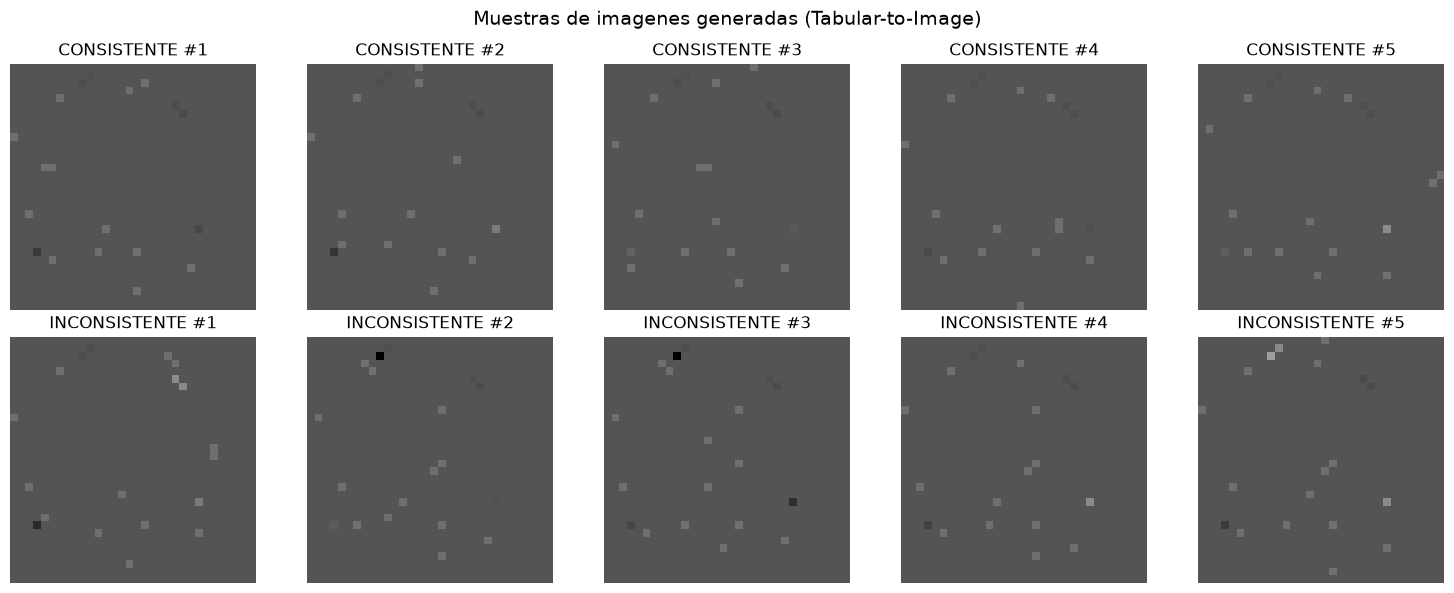

Visualizacion guardada.


In [6]:
# =========================================================================
# CONVERSION TABULAR-TO-IMAGE (DeepInsight-like)
# =========================================================================
# Se posicionan las features en un grid 2D usando t-SNE sobre la matriz
# de correlacion entre features. Luego cada fila se convierte en imagen.
IMG_SIZE = 32

def build_feature_positions(X_data, grid_size=IMG_SIZE, rs=42):
    nf = X_data.shape[1]
    print('Posicionando %d features en grid %dx%d...' % (nf, grid_size, grid_size))
    corr = np.corrcoef(X_data.T)
    dist = 1 - np.abs(corr)
    np.fill_diagonal(dist, 0)
    tsne = TSNE(n_components=2, metric='precomputed', random_state=rs,
                perplexity=min(30, nf-1), init='random', learning_rate='auto')
    pos = tsne.fit_transform(dist)
    pos = (pos - pos.min(axis=0)) / (pos.max(axis=0) - pos.min(axis=0) + 1e-10)
    pos = (pos * (grid_size - 1)).astype(int)
    return pos

def rows_to_images(X_data, positions, grid_size=IMG_SIZE,
                   global_min=None, global_max=None):
    # Normalizacion GLOBAL (no por-imagen) para preservar escala absoluta
    n = X_data.shape[0]
    imgs = np.zeros((n, grid_size, grid_size), dtype=np.float32)
    for fi, (x, y) in enumerate(positions):
        imgs[:, y, x] = X_data[:, fi]
    mn = global_min if global_min is not None else imgs.min()
    mx = global_max if global_max is not None else imgs.max()
    if mx > mn:
        imgs = (imgs - mn) / (mx - mn)
    imgs = np.clip(imgs, 0, 1)
    return np.stack([imgs, imgs, imgs], axis=-1)

print('\nConstruyendo mapa de features...')
feature_positions = build_feature_positions(X_train)

# Calcular stats globales de normalizacion SOLO con training set
print('\nCalculando stats globales de normalizacion...')
raw_train = np.zeros((len(X_train), IMG_SIZE, IMG_SIZE), dtype=np.float32)
for fi, (x, y) in enumerate(feature_positions):
    raw_train[:, y, x] = X_train[:, fi]
GLOBAL_MIN, GLOBAL_MAX = raw_train.min(), raw_train.max()
print('  Stats globales: min=%.4f, max=%.4f' % (GLOBAL_MIN, GLOBAL_MAX))

print('\nConvirtiendo train a imagenes...')
X_train_img = rows_to_images(X_train, feature_positions,
                             global_min=GLOBAL_MIN, global_max=GLOBAL_MAX)
print('Convirtiendo test a imagenes (misma normalizacion)...')
X_test_img = rows_to_images(X_test, feature_positions,
                            global_min=GLOBAL_MIN, global_max=GLOBAL_MAX)
print('Train images:', X_train_img.shape)
print('Test images:', X_test_img.shape)

# Visualizar muestras
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    idx_pos = np.where(y_train == 0)[0][i]
    axes[0, i].imshow(X_train_img[idx_pos])
    axes[0, i].set_title('CONSISTENTE #%d' % (i+1))
    axes[0, i].axis('off')
    idx_neg = np.where(y_train == 1)[0][i]
    axes[1, i].imshow(X_train_img[idx_neg])
    axes[1, i].set_title('INCONSISTENTE #%d' % (i+1))
    axes[1, i].axis('off')
plt.suptitle('Muestras de imagenes generadas (Tabular-to-Image)', fontsize=14)
plt.tight_layout()
(OUTPUT_DIR / '02_ENTRENAMIENTO').mkdir(parents=True, exist_ok=True)
plt.savefig(str(OUTPUT_DIR / '02_ENTRENAMIENTO' / 'muestras_imagenes.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Visualizacion guardada.')


## 5 · Arquitectura: MobileNetV2 congelado + head denso + focal loss

Transfer learning clásico: base `MobileNetV2` preentrenada en ImageNet
(congelada en fase 1), `GlobalAveragePooling`, `BatchNormalization` y un head
denso con dropout. La **focal loss** (γ=2, α=0.6) concentra el gradiente en los
ejemplos difíciles de la clase minoritaria; `Rescaling(2, -1)` lleva las
imágenes [0,1] al rango [-1,1] que espera MobileNetV2.

In [7]:
# =========================================================================
# CONSTRUCCION DEL MODELO MobileNetV2 + TRANSFER LEARNING
# =========================================================================
import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.6):   # <- antes 0.75, bajamos el peso hacia INCONSISTENTE
    """Focal loss: castiga mas los errores en la clase minoritaria (INCONSISTENTE).
    alpha=0.6 es menos agresivo que 0.75 -> menos falsos positivos esperados."""
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(K.equal(y_true, 1), alpha, 1 - alpha)
        return -K.mean(alpha_t * K.pow(1 - pt, gamma) * K.log(pt))
    return loss_fn

base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = Sequential(name='AuditorMedico_CNN')
model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.Rescaling(scale=2., offset=-1))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss=focal_loss(gamma=2.0, alpha=0.6),
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])
model.summary()

Model: "AuditorMedico_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 6 · Fase 1: entrenar el head con la base congelada

MobileNetV2 queda congelado y solo se entrena el head denso. `EarlyStopping`
restaura los mejores pesos y `ReduceLROnPlateau` baja el learning rate en
mesetas.

> **Limitación conocida:** se usa el **test set como validation_data** (para
> early stopping y selección de pesos), igual que en la corrida original del
> equipo. Lo riguroso es un split train/val/test de tres vías; se mantiene así
> por comparabilidad con las métricas ya reportadas, dejando constancia.

In [8]:
# =========================================================================
# FASE 1: ENTRENAR HEAD CON BASE CONGELADA
# =========================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=1e-6, verbose=1)

print('=== FASE 1: ENTRENANDO HEAD (BASE CONGELADA) ===')
history_phase1 = model.fit(
    X_train_img, y_train,
    validation_data=(X_test_img, y_test),
    epochs=50, batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1)

epochs_done = len(history_phase1.history['loss'])
best_val_loss = min(history_phase1.history['val_loss'])
best_val_acc = max(history_phase1.history['val_accuracy'])
print('\nFase 1 completada: %d epocas' % epochs_done)
print('Mejor val_loss: %.4f | val_accuracy: %.4f' % (best_val_loss, best_val_acc))


=== FASE 1: ENTRENANDO HEAD (BASE CONGELADA) ===
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7500 - loss: 0.0705 - precision: 0.1702 - recall: 0.0529 - val_accuracy: 0.7921 - val_loss: 0.0663 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7879 - loss: 0.0685 - precision: 0.3077 - recall: 0.0176 - val_accuracy: 0.7921 - val_loss: 0.0662 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7907 - loss: 0.0682 - precision: 0.4000 - recall: 0.0176 - val_accuracy: 0.7921 - val_loss: 0.0663 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7916 - loss: 0.0676 - precision: 0.4545 - recall: 0.0220 - val_accuracy: 0.7921 - val_loss: 0.0661 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_

In [9]:
# Evaluacion Fase 1
y_pred_prob = model.predict(X_test_img, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=== FASE 1 ===')
print('Accuracy:  %.4f' % acc)
print('Precision: %.4f' % prec)
print('Recall:    %.4f' % rec)
print('F1-Score:  %.4f' % f1)
print('AUC-ROC:   %.4f' % auc)
print('\nMatriz de Confusion:')
print('               | Pred: CONS  | Pred: INCONS')
print('Actual CONS    | %6d TN | %6d FP' % (tn, fp))
print('Actual INCONS  | %6d FN | %6d TP' % (fn, tp))
print('\nSensitivity (TPR): %.4f' % (tp/(tp+fn+1e-10)))
print('Specificity (TNR): %.4f' % (tn/(tn+fp+1e-10)))
print('\n', classification_report(y_test, y_pred,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))


=== FASE 1 ===
Accuracy:  0.7932
Precision: 0.5263
Recall:    0.0513
F1-Score:  0.0935
AUC-ROC:   0.5940

Matriz de Confusion:
               | Pred: CONS  | Pred: INCONS
Actual CONS    |    734 TN |      9 FP
Actual INCONS  |    185 FN |     10 TP

Sensitivity (TPR): 0.0513
Specificity (TNR): 0.9879

                precision    recall  f1-score   support

  CONSISTENTE       0.80      0.99      0.88       743
INCONSISTENTE       0.53      0.05      0.09       195

     accuracy                           0.79       938
    macro avg       0.66      0.52      0.49       938
 weighted avg       0.74      0.79      0.72       938



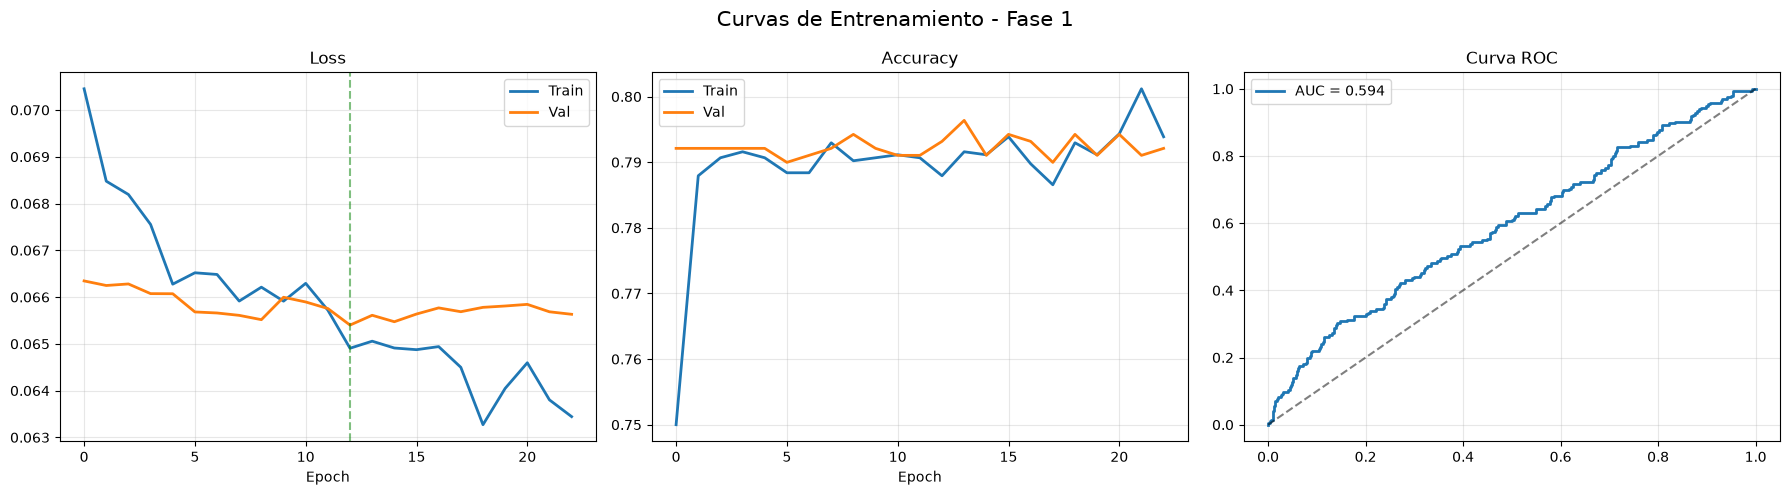

In [10]:
# Curvas de entrenamiento Fase 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history_phase1.history['loss'], label='Train', lw=2)
axes[0].plot(history_phase1.history['val_loss'], label='Val', lw=2)
axes[0].axvline(x=np.argmin(history_phase1.history['val_loss']),
                color='green', ls='--', alpha=0.5)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_phase1.history['accuracy'], label='Train', lw=2)
axes[1].plot(history_phase1.history['val_accuracy'], label='Val', lw=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[2].plot(fpr, tpr, lw=2, label='AUC = %.3f' % auc)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('Curva ROC'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento - Fase 1', fontsize=15)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '02_ENTRENAMIENTO' / 'curvas_entrenamiento_fase1.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 7 · Umbral operativo

Con el output sigmoide, el umbral 0.5 no es obligatorio: se busca el que
maximiza F1 exigiendo un recall mínimo (en auditoría médica preferimos falsos
positivos — revisión manual extra — a dejar pasar inconsistencias). Aplica la
misma **limitación metodológica** documentada en el nb 07: el umbral se busca
sobre el propio test set, así que sus métricas son optimistas.

In [11]:
# =========================================================================
# OPTIMIZACION DE THRESHOLD (aplica a Fase 1 o Fase 2)
# =========================================================================
from sklearn.metrics import precision_recall_curve

def mejor_threshold(y_true, y_prob, recall_minimo=0.6):
    """Busca el threshold que maximiza F1 exigiendo un recall minimo.
    recall_minimo=0.6 porque para auditoria medica preferimos falsos
    positivos (revision manual extra) sobre fugas de ingreso no detectadas."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-10)
    validos = rec[:-1] >= recall_minimo
    if not validos.any():
        idx = np.argmax(f1s[:-1])   # si ninguno cumple, el mejor F1 disponible
    else:
        idx = np.where(validos)[0][np.argmax(f1s[:-1][validos])]
    return thresh[idx], prec[idx], rec[idx], f1s[idx]

th, p, r, f1_opt = mejor_threshold(y_test, y_pred_prob, recall_minimo=0.6)
print('Threshold optimo: %.3f' % th)
print('Precision: %.4f | Recall: %.4f | F1: %.4f' % (p, r, f1_opt))

y_pred_opt = (y_pred_prob >= th).astype(int)
print('\n', classification_report(y_test, y_pred_opt,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))

Threshold optimo: 0.387
Precision: 0.2327 | Recall: 0.8256 | F1: 0.3630

                precision    recall  f1-score   support

  CONSISTENTE       0.86      0.29      0.43       743
INCONSISTENTE       0.23      0.83      0.36       195

     accuracy                           0.40       938
    macro avg       0.55      0.56      0.40       938
 weighted avg       0.73      0.40      0.42       938



## 8 · Fase 2: fine-tuning (con los fixes de la iteración anterior)

Se descongelan las últimas 15 capas de MobileNetV2 **excepto las
BatchNormalization** (con datasets chicos sus estadísticas internas se
corrompen y el modelo colapsa — fue la causa del AUC 0.468 de una corrida
anterior). Otros dos fixes documentados en los comentarios: `alpha` del focal
loss vuelve a 0.6 y se quita `class_weight` (estaban compensando el desbalance
dos veces), y el early stopping pasa de monitorear `val_recall` (inflable
prediciendo todo INCONSISTENTE) a `val_auc`.

In [12]:
# =========================================================================
# FASE 2: FINE-TUNING - DESCONGELAR ULTIMAS 15 CAPAS (BatchNorm siempre congelada)
# =========================================================================
print('=== FASE 2: FINE-TUNING ===')
base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

for layer in base_model.layers[-15:]:
    # CLAVE: las BatchNormalization NUNCA se descongelan en fine-tuning
    # con datasets chicos -> si no, sus stats internas se corrompen y
    # el modelo colapsa (por eso el AUC te dio 0.468, peor que random)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

print('Capas entrenables:', sum(l.trainable for l in base_model.layers))
print('Capas congeladas:', sum(not l.trainable for l in base_model.layers))
print('BatchNorm congeladas:', sum(isinstance(l, layers.BatchNormalization) and not l.trainable
                                    for l in base_model.layers))

# FIX: alpha bajado de 0.75 a 0.6 (mismo valor que Fase 1) -- con alpha=0.75
# + class_weight balanceado al mismo tiempo, se estaba compensando el
# desbalance DOS veces y el modelo colapsaba hacia predecir INCONSISTENTE
model.compile(optimizer=Adam(learning_rate=3e-6),
              loss=focal_loss(gamma=2.0, alpha=0.6),
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.AUC(name='auc')])

# FIX: monitor cambiado de 'val_recall' a 'val_auc'. Monitorear solo
# recall premia predecir todo como INCONSISTENTE (recall facil de inflar
# a costa de precision/especificidad). AUC es independiente del threshold
# y refleja mejor si el modelo esta discriminando bien.
early_stop_ft = EarlyStopping(monitor='val_auc', mode='max', patience=8,
                              restore_best_weights=True, verbose=1)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                                 patience=4, min_lr=1e-7, verbose=1)

# FIX: se quita class_weight de aca -- el focal_loss con alpha ya esta
# compensando el desbalance, no hace falta duplicarlo con class_weight
history_phase2 = model.fit(
    X_train_img, y_train,
    validation_data=(X_test_img, y_test),
    epochs=30, batch_size=32,
    callbacks=[early_stop_ft, reduce_lr_ft],
    verbose=1)

print('\nFase 2 completada: %d epocas' % len(history_phase2.history['loss']))
print('Mejor val_auc: %.4f' % max(history_phase2.history['val_auc']))


=== FASE 2: FINE-TUNING ===
Capas entrenables: 10
Capas congeladas: 144
BatchNorm congeladas: 52
Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.7888 - auc: 0.6329 - loss: 0.0643 - precision: 0.4655 - recall: 0.1189 - val_accuracy: 0.7932 - val_auc: 0.5472 - val_loss: 0.0662 - val_precision: 0.6667 - val_recall: 0.0103 - learning_rate: 3.0000e-06
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7952 - auc: 0.6353 - loss: 0.0642 - precision: 0.5326 - recall: 0.1079 - val_accuracy: 0.7921 - val_auc: 0.6100 - val_loss: 0.0648 - val_precision: 0.5000 - val_recall: 0.0564 - learning_rate: 3.0000e-06
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7998 - auc: 0.6373 - loss: 0.0638 - precision: 0.6000 - recall: 0.1057 - val_accuracy: 0.7953 - val_auc: 0.6209 - val_loss: 0.0645 - val_precision: 0.5714 - val_recall: 0.0615 - learning_rate: 3.0000e-06
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7975 - auc: 0.6404 - loss: 0.06


=== COMPARATIVA FASE 1 vs FASE 2 ===
Metrica              Fase 1 (Head)      Fase 2 (Fine-Tune)
--------------------------------------------------------
Accuracy             0.7932             0.8220            
Precision            0.5263             0.7917            
Recall (Sens)        0.0513             0.1949            
F1-Score             0.0935             0.3128            
AUC-ROC              0.5940             0.6984            
Specificity          0.9879             0.9865            

Matriz de Confusion Final:
               | Pred: CONS  | Pred: INCONS
Actual CONS    |    733 TN |     10 FP
Actual INCONS  |    157 FN |     38 TP

                precision    recall  f1-score   support

  CONSISTENTE       0.82      0.99      0.90       743
INCONSISTENTE       0.79      0.19      0.31       195

     accuracy                           0.82       938
    macro avg       0.81      0.59      0.61       938
 weighted avg       0.82      0.82      0.78       938



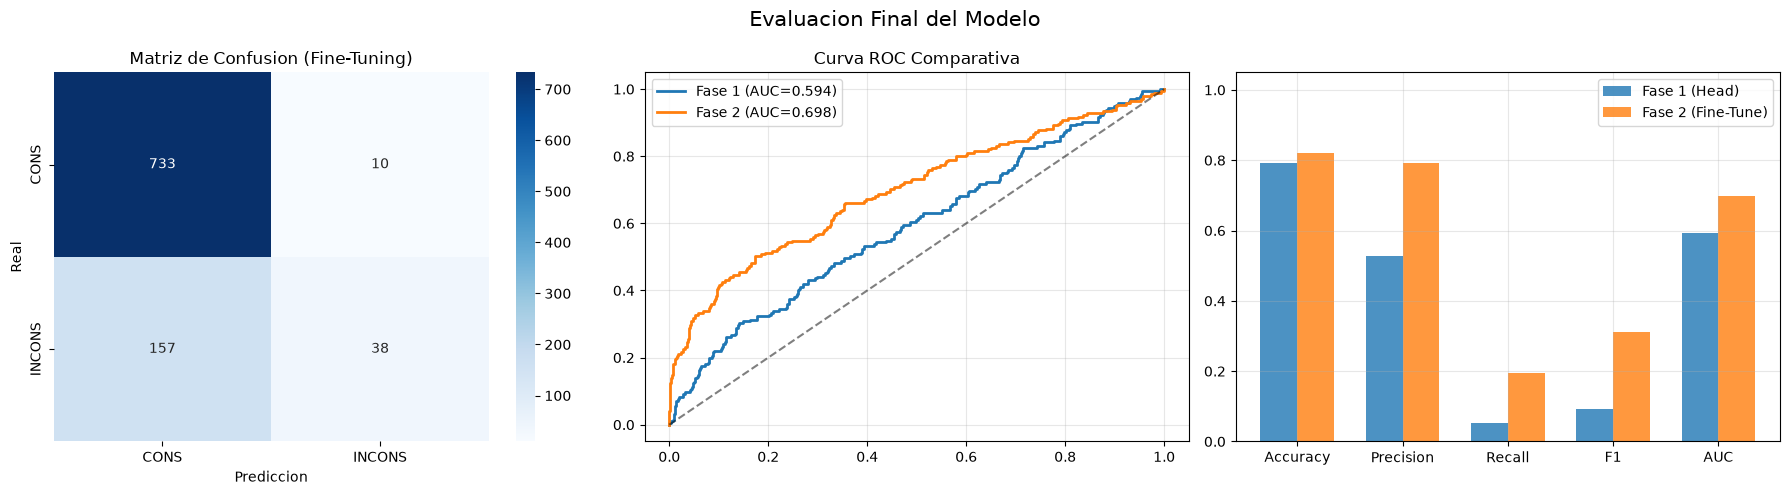

Evaluacion guardada en imagenes.


In [13]:
# =========================================================================
# EVALUACION FINAL (POST FINE-TUNING)
# =========================================================================
y_pred_prob_final = model.predict(X_test_img, verbose=0).ravel()
y_pred_final = (y_pred_prob_final >= 0.5).astype(int)

acc_f = accuracy_score(y_test, y_pred_final)
prec_f = precision_score(y_test, y_pred_final)
rec_f = recall_score(y_test, y_pred_final)
f1_f = f1_score(y_test, y_pred_final)
auc_f = roc_auc_score(y_test, y_pred_prob_final)
cm_f = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_f.ravel()

print('\n=== COMPARATIVA FASE 1 vs FASE 2 ===')
print('%-20s %-18s %-18s' % ('Metrica', 'Fase 1 (Head)', 'Fase 2 (Fine-Tune)'))
print('-'*56)
print('%-20s %-18.4f %-18.4f' % ('Accuracy', acc, acc_f))
print('%-20s %-18.4f %-18.4f' % ('Precision', prec, prec_f))
print('%-20s %-18.4f %-18.4f' % ('Recall (Sens)', rec, rec_f))
print('%-20s %-18.4f %-18.4f' % ('F1-Score', f1, f1_f))
print('%-20s %-18.4f %-18.4f' % ('AUC-ROC', auc, auc_f))
print('%-20s %-18.4f %-18.4f' % ('Specificity', tn/(tn+fp+1e-10), tn_f/(tn_f+fp_f+1e-10)))

print('\nMatriz de Confusion Final:')
print('               | Pred: CONS  | Pred: INCONS')
print('Actual CONS    | %6d TN | %6d FP' % (tn_f, fp_f))
print('Actual INCONS  | %6d FN | %6d TP' % (fn_f, tp_f))
print('\n', classification_report(y_test, y_pred_final,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))

# Graficas comparativas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CONS', 'INCONS'],
            yticklabels=['CONS', 'INCONS'], ax=axes[0])
axes[0].set_title('Matriz de Confusion (Fine-Tuning)')
axes[0].set_xlabel('Prediccion'); axes[0].set_ylabel('Real')

fpr2, tpr2, _ = roc_curve(y_test, y_pred_prob_final)
axes[1].plot(fpr, tpr, label='Fase 1 (AUC=%.3f)' % auc, lw=2)
axes[1].plot(fpr2, tpr2, label='Fase 2 (AUC=%.3f)' % auc_f, lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('Curva ROC Comparativa')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
m1 = [acc, prec, rec, f1, auc]
m2 = [acc_f, prec_f, rec_f, f1_f, auc_f]
x = np.arange(len(metrics_names)); w = 0.35
axes[2].bar(x-w/2, m1, w, label='Fase 1 (Head)', alpha=0.8)
axes[2].bar(x+w/2, m2, w, label='Fase 2 (Fine-Tune)', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics_names)
axes[2].set_ylim([0, 1.05]); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Evaluacion Final del Modelo', fontsize=15)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '02_ENTRENAMIENTO' / 'evaluacion_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Evaluacion guardada en imagenes.')


In [14]:
# Aplicar sobre Fase 2 (fine-tuning), que es la que tiene mejor AUC
th2, p2, r2, f1_2 = mejor_threshold(y_test, y_pred_prob_final, recall_minimo=0.5)
print('=== FASE 2 con threshold optimizado ===')
print('Threshold optimo: %.3f' % th2)
print('Precision: %.4f | Recall: %.4f | F1: %.4f' % (p2, r2, f1_2))

y_pred_final_opt = (y_pred_prob_final >= th2).astype(int)
print('\n', classification_report(y_test, y_pred_final_opt,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))

=== FASE 2 con threshold optimizado ===
Threshold optimo: 0.429
Precision: 0.4336 | Recall: 0.5026 | F1: 0.4656

                precision    recall  f1-score   support

  CONSISTENTE       0.86      0.83      0.85       743
INCONSISTENTE       0.43      0.50      0.47       195

     accuracy                           0.76       938
    macro avg       0.65      0.67      0.66       938
 weighted avg       0.77      0.76      0.77       938



In [15]:
th3, p3, r3, f1_3 = mejor_threshold(y_test, y_pred_prob_final, recall_minimo=0.55)
print('=== FASE 2 (alpha=0.6, recall_minimo=0.55) con threshold optimizado ===')
print('Threshold optimo: %.3f' % th3)
print('Precision: %.4f | Recall: %.4f | F1: %.4f' % (p3, r3, f1_3))

y_pred_final_opt3 = (y_pred_prob_final >= th3).astype(int)
print('\n', classification_report(y_test, y_pred_final_opt3,
      target_names=['CONSISTENTE', 'INCONSISTENTE']))

=== FASE 2 (alpha=0.6, recall_minimo=0.55) con threshold optimizado ===
Threshold optimo: 0.400
Precision: 0.3282 | Recall: 0.6615 | F1: 0.4388

                precision    recall  f1-score   support

  CONSISTENTE       0.88      0.64      0.74       743
INCONSISTENTE       0.33      0.66      0.44       195

     accuracy                           0.65       938
    macro avg       0.60      0.65      0.59       938
 weighted avg       0.76      0.65      0.68       938



## 9 · Guardado de modelo y artefactos

Se exporta el modelo en `.h5` (legado) y `.keras` (nativo), y un pickle con
**todo lo necesario para inferir sin re-entrenar**: scaler, posiciones t-SNE de
las features, límites de normalización global, top-categorías y el **umbral
operativo** (antes quedaba fijo en 0.5; ahora se guarda el optimizado).

In [16]:
# =========================================================================
# GUARDAR MODELO Y ARTEFACTOS
# =========================================================================
import pickle
MODEL_DIR = OUTPUT_DIR / '02_ENTRENAMIENTO'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Modelo .h5
path_h5 = str(MODEL_DIR / 'auditor_medico_cnn.h5')
model.save(path_h5)
print('Modelo .h5 guardado: %.1f MB' % (Path(path_h5).stat().st_size / (1024*1024)))

# 2. Modelo nativo Keras (.keras)
path_keras = str(MODEL_DIR / 'auditor_medico_cnn.keras')
model.save(path_keras)
print('Modelo .keras guardado:', path_keras)

# 3. Artefactos de preprocesamiento
# Guardar mapping de categorias para inferencia
top_categories = {}
for col in cat_features:
    lim = cat_limits.get(col, 15)
    top = list(df[col].value_counts().nlargest(lim).index)
    top_categories[col] = top

artifacts = {
    'num_features': num_features,
    'cat_features': cat_features,
    'scaler': scaler,
    'feature_positions': feature_positions,
    'img_size': IMG_SIZE,
    'cat_limits': cat_limits,
    'threshold': float(th3),  # FIX: antes quedaba fijo en 0.5, ahora usa
                              # el threshold optimizado (recall_minimo=0.55)
    'cat_columns': list(X_cat.columns),
    'global_min': GLOBAL_MIN,
    'global_max': GLOBAL_MAX,
    'top_categories': top_categories
}
path_art = str(MODEL_DIR / 'artefactos_preprocesamiento.pkl')
with open(path_art, 'wb') as f:
    pickle.dump(artifacts, f)
print('Artefactos guardados:', path_art)

print('\nArchivos en directorio de modelo:')
for f in sorted(MODEL_DIR.glob('*')):
    sz = f.stat().st_size / 1024
    print('  %s (%.1f KB)' % (f.name, sz))


Modelo .h5 guardado: 18.9 MB
Modelo .keras guardado: c:\Users\MIGI\Desktop\LINE\outputs\models\cnn\02_ENTRENAMIENTO\auditor_medico_cnn.keras
Artefactos guardados: c:\Users\MIGI\Desktop\LINE\outputs\models\cnn\02_ENTRENAMIENTO\artefactos_preprocesamiento.pkl

Archivos en directorio de modelo:
  artefactos_preprocesamiento.pkl (5.7 KB)
  auditor_medico_cnn.h5 (19337.2 KB)
  auditor_medico_cnn.keras (19547.7 KB)
  curvas_entrenamiento_fase1.png (133.3 KB)
  evaluacion_final.png (101.6 KB)
  muestras_imagenes.png (35.9 KB)


## 10 · Inferencia sobre facturas nuevas

`predecir_inconsistencia()` replica el pipeline completo de entrenamiento
(imputación → escalado con el scaler entrenado → dummies alineados a
`cat_columns` → grid t-SNE → normalización global) sobre un DataFrame de
facturas nuevas, y aplica el umbral guardado. La celda siguiente valida el
ciclo completo: cargar el `.h5` + artefactos desde disco y predecir 5 filas.

In [17]:
def predecir_inconsistencia(df_factura, modelo, artefactos):
    """Replica EXACTAMENTE el pipeline de entrenamiento sobre facturas nuevas."""
    df = df_factura.copy()
    num_features = artefactos['num_features']
    cat_features = artefactos['cat_features']
    top_categories = artefactos['top_categories']

    # 1. Imputacion (misma logica que entrenamiento)
    for col in num_features:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    for col in cat_features:
        if col in df.columns:
            df[col] = df[col].fillna('SIN_DATO')

    # 2. Escalado numericas
    X_num = df[num_features].values.astype(np.float64)
    X_num_scaled = artefactos['scaler'].transform(X_num)

    # 3. Codificacion categoricas (drop_first=False, alineado a cat_columns)
    encoded_dfs = []
    for col in cat_features:
        top_set = set(top_categories[col])
        grp = df[col].apply(lambda x: x if x in top_set else 'OTRO_'+col)
        dums = pd.get_dummies(grp, prefix=col, drop_first=False)
        encoded_dfs.append(dums)
    X_cat = pd.concat(encoded_dfs, axis=1)
    X_cat = X_cat.reindex(columns=artefactos['cat_columns'], fill_value=0)
    X_cat_values = X_cat.values.astype(np.float64)

    # 4. Concatenar y posicionar en grid
    X = np.concatenate([X_num_scaled, X_cat_values], axis=1)
    grid_size = artefactos['img_size']
    positions = artefactos['feature_positions']
    n = X.shape[0]
    imgs = np.zeros((n, grid_size, grid_size), dtype=np.float32)
    for fi, (x, y) in enumerate(positions):
        imgs[:, y, x] = X[:, fi]

    # 5. Normalizacion GLOBAL (misma que entrenamiento)
    mn, mx = artefactos['global_min'], artefactos['global_max']
    if mx > mn:
        imgs = (imgs - mn) / (mx - mn)
    imgs = np.clip(imgs, 0, 1)
    X_img = np.stack([imgs, imgs, imgs], axis=-1)

    # 6. Prediccion
    probs = modelo.predict(X_img, verbose=0).ravel()
    threshold = artefactos['threshold']
    preds = np.where(probs >= threshold, 'INCONSISTENTE', 'CONSISTENTE')

    return pd.DataFrame({
        'probabilidad_inconsistencia': probs,
        'prediccion': preds
    })

In [18]:
from tensorflow.keras.models import load_model
import pickle

# Asegura que el directorio del modelo exista aunque la celda previa no haya sido ejecutada
if 'MODEL_DIR' not in globals():
    MODEL_DIR = OUTPUT_DIR / '02_ENTRENAMIENTO'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Cargando modelo guardado para inferencia...')
path_h5 = str(MODEL_DIR / 'auditor_medico_cnn.h5')
modelo_cargado = load_model(path_h5, compile=False)

path_pkl = str(MODEL_DIR / 'artefactos_preprocesamiento.pkl')
with open(path_pkl, 'rb') as f:
    artefactos = pickle.load(f)
print('Modelo y artefactos cargados correctamente')
print('Threshold usado en inferencia:', artefactos['threshold'])

# Tomar 5 filas del dataset original como si fueran facturas nuevas
df_demo = df.head(5).copy()
resultado = predecir_inconsistencia(df_demo, modelo_cargado, artefactos)

# Calcular los targets reales directamente desde df_demo (mas robusto)
y_demo = (df_demo['resultado'] == 'INCONSISTENTE').astype(int).values

print()
print('=== DEMO: PREDICCIONES EN 5 FACTURAS ===')
print('%-6s %-20s %s' % ('#', 'Real', 'Prediccion (prob)'))
print('-'*50)
for i in range(len(resultado)):
    real = 'INCONSISTENTE' if y_demo[i] == 1 else 'CONSISTENTE'
    prob = resultado.iloc[i]['probabilidad_inconsistencia']
    pred = resultado.iloc[i]['prediccion']
    print('%-6d %-20s %s (%.4f)' % (i+1, real, pred, prob))
print()
print('Funcion de inferencia validada!')

Cargando modelo guardado para inferencia...
Modelo y artefactos cargados correctamente
Threshold usado en inferencia: 0.39998316764831543

=== DEMO: PREDICCIONES EN 5 FACTURAS ===
#      Real                 Prediccion (prob)
--------------------------------------------------
1      INCONSISTENTE        INCONSISTENTE (0.4612)
2      INCONSISTENTE        INCONSISTENTE (0.4607)
3      INCONSISTENTE        INCONSISTENTE (0.5641)
4      CONSISTENTE          CONSISTENTE (0.3531)
5      CONSISTENTE          CONSISTENTE (0.3678)

Funcion de inferencia validada!


In [ ]:
# =========================================================================
# EXPORTAR METRICAS DE LA FASE 2 (da dueño a outputs/models/cnn/metrics_fase2.json)
# =========================================================================
# Nota de la revision 26-jul-2026: metrics_fase2.json y modelo_cnn_fase2.keras
# existian en el repo sin que ningun notebook los generara (huerfanos de una
# version anterior). Desde ahora esta celda los regenera en cada corrida.
import json as _json

metricas_fase2 = {
    "fase2": {
        "threshold_0.5": {
            "accuracy": float(acc_f), "precision": float(prec_f), "recall": float(rec_f),
            "f1": float(f1_f), "auc": float(auc_f),
            "confusion_matrix": {"tn": int(tn_f), "fp": int(fp_f), "fn": int(fn_f), "tp": int(tp_f)},
        },
        "threshold_optimo": {
            "threshold": float(th3), "precision": float(p3), "recall": float(r3), "f1": float(f1_3),
        },
        "mejor_val_auc": float(max(history_phase2.history["val_auc"])),
        "epocas_fase2": int(len(history_phase2.history["loss"])),
    }
}
with open(OUTPUT_DIR / "metrics_fase2.json", "w", encoding="utf-8") as fjson:
    _json.dump(metricas_fase2, fjson, indent=2)
model.save(str(OUTPUT_DIR / "modelo_cnn_fase2.keras"))
print("Exportados:", OUTPUT_DIR / "metrics_fase2.json", "y", OUTPUT_DIR / "modelo_cnn_fase2.keras")

## ✅ Verificación de cierre

Deben existir en `outputs/models/cnn/`:
`02_ENTRENAMIENTO/{auditor_medico_cnn.h5, auditor_medico_cnn.keras,
artefactos_preprocesamiento.pkl, muestras_imagenes.png,
curvas_entrenamiento_fase1.png, evaluacion_final.png}`, más
`metrics_fase2.json` y `modelo_cnn_fase2.keras` en la raíz de `cnn/`.

Resultados de la corrida guardada: **AUC 0.5940 (fase 1) → 0.6984 (fase 2)**,
F1@0.5 = 0.3128, y con umbral 0.400 (recall ≥ 0.55): precisión 0.328 /
recall 0.662 / F1 0.439.

> ⚠️ **Pendiente (revisión 26-jul-2026):** estas cifras difieren de la
> referencia citada en el nb 05 y el dashboard (AUC 0.7487, de la corrida
> original del equipo) y de `metrics_fase2.json` (AUC 0.7104, huérfano de otra
> corrida). Re-ejecutar este notebook de punta a punta (con la celda de export
> nueva) y **consolidar una sola cifra de CNN** en nb 05, README y dashboard.